In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
import seaborn as sns

In [4]:
df_DA_DE = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_DE = df_DA_DE.dropna(subset=['salary_year_avg'])

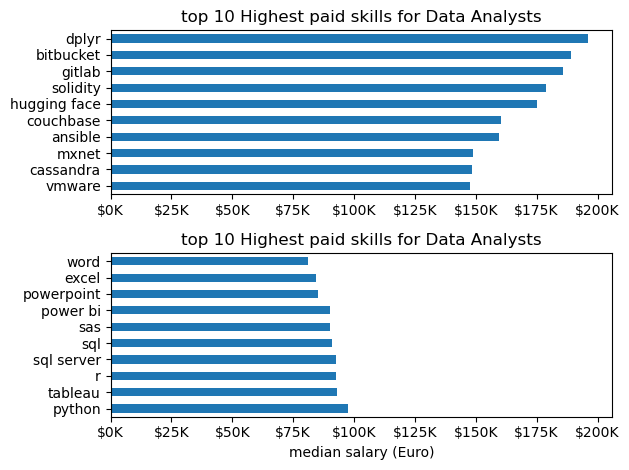

In [5]:
df_DA_DE = df_DA_DE.explode('job_skills')
df_DA_DE[['salary_year_avg','job_skills']]
df_DA_group = df_DA_DE.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_top_pay = df_DA_group.sort_values(by='median', ascending=False).head(10)
df_DA_Skills = df_DA_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)
fig, ax = plt.subplots(2,1)

df_DA_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].invert_yaxis()
ax[0].set_title('top 10 Highest paid skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
from matplotlib.ticker import FuncFormatter
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


df_DA_Skills.plot(kind='barh', y='median', ax=ax[1],legend=False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('top 10 Highest paid skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('median salary (Euro)')
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
fig.tight_layout()


C:\Users\BS\AppData\Local\Temp\ipykernel_12312\1403156453.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], palette='viridis')
C:\Users\BS\AppData\Local\Temp\ipykernel_12312\1403156453.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_DA_Skills, x='median', y=df_DA_Skills.index, ax=ax[1], palette='magma')


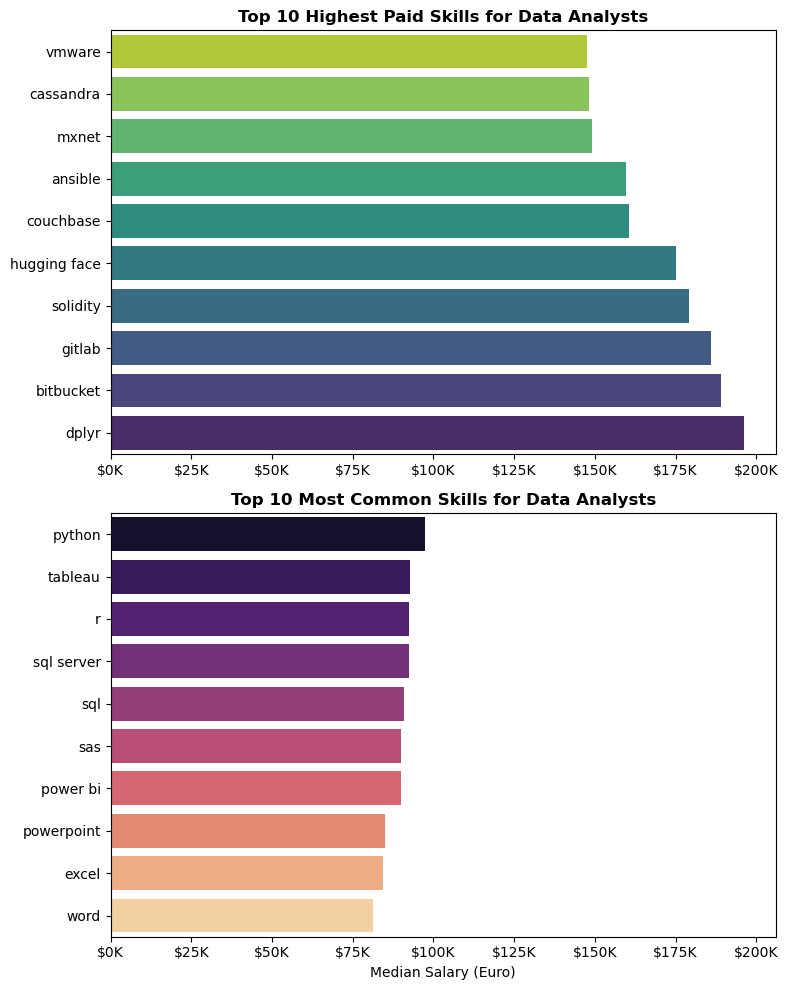

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(8, 10))

# ----- Top Chart: Highest Paying Skills -----
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], palette='viridis')
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts', fontsize=12, fontweight='bold')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# ----- Bottom Chart: Most Common Skills -----
sns.barplot(data=df_DA_Skills, x='median', y=df_DA_Skills.index, ax=ax[1], palette='magma')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most Common Skills for Data Analysts', fontsize=12, fontweight='bold')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (Euro)')
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# ----- Layout -----
fig.tight_layout()
plt.show()